<a href="https://colab.research.google.com/github/shriom17/MedFlow-OpenEnv/blob/main/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/shriom17/MedFlow-OpenEnv.git
%cd MedFlow-OpenEnv

fatal: destination path 'MedFlow-OpenEnv' already exists and is not an empty directory.
/content/MedFlow-OpenEnv


In [2]:
!ls

app			  openenv	  requirements.txt  train
Dockerfile		  openenv.yaml	  reward_curve.png  Training.ipynb
hftrl_colab.md		  output.txt	  scripts	    training_log.csv
inference.py		  plot_graph.py   server	    uv.lock
loss_curve.png		  __pycache__	  templates
MedFlow-OpenEnv		  pyproject.toml  test_api.py
medflow_openenv.egg-info  README.md	  tests


In [3]:
!pwd

/content/MedFlow-OpenEnv


In [4]:
!pip install -e . --no-deps

Obtaining file:///content/MedFlow-OpenEnv
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for medflow-openenv (pyproject.toml) ... done
  Created wheel for medflow-openenv: filename=medflow_openenv-1.0.0-0.editable-py3-none-any.whl size=7387 sha256=a8c6a04f1525cc01d65840189b213e31cfaa78c2f3ddd0e7ed6a79881b8ba6e7
  Stored in directory: /tmp/pip-ephem-wheel-cache-uswzz0i7/wheels/cf/44/8d/c3cda9fef6bc2301d8e5ec2d8f5254234e618b299a7a04dc93
Successfully built medflow-openenv
  Attempting uninstall: medflow-openenv
    Found existing installation: medflow-openenv 1.0.0
    Uninstalling medflow-openenv-1.0.0:
      Successfully uninstalled medflow-openenv-1.0.0


In [5]:
!pip install uvicorn==0.24.0
!pip install fastapi==0.104.1
!pip install pydantic==2.12.5
!pip install openai==2.30.0
!pip install matplotlib==3.10.8

  Using cached uvicorn-0.24.0-py3-none-any.whl.metadata (6.4 kB)
Using cached uvicorn-0.24.0-py3-none-any.whl (59 kB)
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.46.0
    Uninstalling uvicorn-0.46.0:
      Successfully uninstalled uvicorn-0.46.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
medflow-openenv 1.0.0 requires fastapi==0.104.1, but you have fastapi 0.136.1 which is incompatible.
google-adk 1.29.0 requires starlette<1.0.0,>=0.49.1, but you have starlette 1.0.0 which is incompatible.
google-adk 1.29.0 requires uvicorn<1.0.0,>=0.34.0, but you have uvicorn 0.24.0 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.
gradio 5.50.0 requires starlette<1.0,>=0.40.0, but you have starlette 1.0.0 which is incompatible.
mcp 1.27.0 requires uvicorn>=0.31.1; sys_p

In [6]:
# Python cell
import sys, os
print("cwd:", os.getcwd())
# Checking for 'openenv/__init__.py' might be misleading if the package is named medflow_openenv
# print("openenv exists:", os.path.exists("openenv/__init__.py"))
sys.path.append(os.getcwd())
import app
print(app)

cwd: /content/MedFlow-OpenEnv
<module 'app' from '/content/MedFlow-OpenEnv/app/__init__.py'>


In [7]:
!cat requirements.txt

openenv-core==0.2.1

fastapi==0.104.1
uvicorn[standard]==0.24.0
pydantic==2.12.5
anyio==3.7.1
starlette==0.27.0

websockets==15.0.1
openai==2.30.0
matplotlib==3.10.8

fastmcp==3.1.1
mcp==1.26.0

In [8]:
!pip install openenv-core==0.2.1

  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached uvicorn-0.46.0-py3-none-any.whl.metadata (6.7 kB)
Using cached fastapi-0.136.1-py3-none-any.whl (117 kB)
Using cached uvicorn-0.46.0-py3-none-any.whl (70 kB)
Using cached anyio-4.13.0-py3-none-any.whl (114 kB)
Using cached starlette-1.0.0-py3-none-any.whl (72 kB)
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.24.0
    Uninstalling uvicorn-0.24.0:
      Successfully uninstalled uvicorn-0.24.0
  Attempting uninstall: anyio
    Found existing installation: anyio 3.7.1
    Uninstalling anyio-3.7.1:
      Successfully uninstalled anyio-3.7.1
  Attempting uninstall: starlette
    Found existing installation: starlette 0.27.0
    Uninstalling starlette-0.27.0:
      Successfully uninstalled starlette-0.27.0
  Attempting uninstall: fastapi
    Found existing in

In [9]:
!pwd
!ls -la

/content/MedFlow-OpenEnv
total 764
drwxr-xr-x 13 root root   4096 Apr 25 03:32 .
drwxr-xr-x  1 root root   4096 Apr 25 02:27 ..
drwxr-xr-x  3 root root   4096 Apr 25 02:28 app
-rw-r--r--  1 root root    437 Apr 25 02:27 Dockerfile
drwxr-xr-x  8 root root   4096 Apr 25 02:27 .git
-rw-r--r--  1 root root   1519 Apr 25 02:27 .gitattributes
-rw-r--r--  1 root root    513 Apr 25 02:27 .gitignore
-rw-r--r--  1 root root   2084 Apr 25 02:27 hftrl_colab.md
-rw-r--r--  1 root root  11445 Apr 25 02:27 inference.py
-rw-r--r--  1 root root  10798 Apr 25 03:25 loss_curve.png
drwxr-xr-x 12 root root   4096 Apr 25 03:34 MedFlow-OpenEnv
drwxr-xr-x  2 root root   4096 Apr 25 03:46 medflow_openenv.egg-info
drwxr-xr-x  4 root root   4096 Apr 25 02:28 openenv
-rw-r--r--  1 root root   2582 Apr 25 02:27 openenv.yaml
-rw-r--r--  1 root root  16054 Apr 25 02:27 output.txt
-rw-r--r--  1 root root    998 Apr 25 02:27 plot_graph.py
drwxr-xr-x  2 root root   4096 Apr 25 02:30 __pycache__
-rw-r--r--  1 root root 

In [10]:
!git branch -a

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/assets
  remotes/origin/main


In [11]:
!pwd
!ls -la
!ls -la MedFlow-OpenEnv
!ls -la MedFlow-OpenEnv/openenv

/content/MedFlow-OpenEnv
total 764
drwxr-xr-x 13 root root   4096 Apr 25 03:32 .
drwxr-xr-x  1 root root   4096 Apr 25 02:27 ..
drwxr-xr-x  3 root root   4096 Apr 25 02:28 app
-rw-r--r--  1 root root    437 Apr 25 02:27 Dockerfile
drwxr-xr-x  8 root root   4096 Apr 25 02:27 .git
-rw-r--r--  1 root root   1519 Apr 25 02:27 .gitattributes
-rw-r--r--  1 root root    513 Apr 25 02:27 .gitignore
-rw-r--r--  1 root root   2084 Apr 25 02:27 hftrl_colab.md
-rw-r--r--  1 root root  11445 Apr 25 02:27 inference.py
-rw-r--r--  1 root root  10798 Apr 25 03:25 loss_curve.png
drwxr-xr-x 12 root root   4096 Apr 25 03:34 MedFlow-OpenEnv
drwxr-xr-x  2 root root   4096 Apr 25 03:46 medflow_openenv.egg-info
drwxr-xr-x  4 root root   4096 Apr 25 02:28 openenv
-rw-r--r--  1 root root   2582 Apr 25 02:27 openenv.yaml
-rw-r--r--  1 root root  16054 Apr 25 02:27 output.txt
-rw-r--r--  1 root root    998 Apr 25 02:27 plot_graph.py
drwxr-xr-x  2 root root   4096 Apr 25 02:30 __pycache__
-rw-r--r--  1 root root 

In [12]:
import sys
sys.path.append('/content/MedFlow-OpenEnv/MedFlow-OpenEnv')
import openenv
print(openenv)

<module 'openenv' from '/content/MedFlow-OpenEnv/openenv/__init__.py'>


In [13]:
!python -c "import openenv; print(openenv.__file__)"

/content/MedFlow-OpenEnv/openenv/__init__.py


In [14]:
from openenv.core.env_server.types import Action, Observation, State

In [15]:
import openenv
print(openenv.__file__)

/content/MedFlow-OpenEnv/openenv/__init__.py


In [16]:
import openenv.core.env_server.types as t
print(dir(t))

['Action', 'Any', 'Observation', 'State', 'TypedDict', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__']


In [17]:
import sys
sys.path.insert(0, "/content/MedFlow-OpenEnv")

In [18]:
from openenv.core.env_server.types import Action, Observation, State

In [19]:
import openenv
print(openenv.__file__)

/content/MedFlow-OpenEnv/openenv/__init__.py


In [20]:
import sys
sys.path.append("/content/MedFlow-OpenEnv")

In [21]:
from openenv.core.env_server.types import Action, Observation, State
print("CORE OK")

CORE OK


In [22]:
from app.env import HospitalQueueEnvironment

env = HospitalQueueEnvironment()
print("ENV OK 🚀")

ENV OK 🚀


In [23]:
!python -m compileall .

Listing '.'...
Listing './.git'...
Listing './.git/branches'...
Listing './.git/hooks'...
Listing './.git/info'...
Listing './.git/logs'...
Listing './.git/logs/refs'...
Listing './.git/logs/refs/heads'...
Listing './.git/logs/refs/remotes'...
Listing './.git/logs/refs/remotes/origin'...
Listing './.git/objects'...
Listing './.git/objects/info'...
Listing './.git/objects/pack'...
Listing './.git/refs'...
Listing './.git/refs/heads'...
Listing './.git/refs/remotes'...
Listing './.git/refs/remotes/origin'...
Listing './.git/refs/tags'...
Listing './MedFlow-OpenEnv'...
Listing './MedFlow-OpenEnv/.git'...
Listing './MedFlow-OpenEnv/.git/branches'...
Listing './MedFlow-OpenEnv/.git/hooks'...
Listing './MedFlow-OpenEnv/.git/info'...
Listing './MedFlow-OpenEnv/.git/logs'...
Listing './MedFlow-OpenEnv/.git/logs/refs'...
Listing './MedFlow-OpenEnv/.git/logs/refs/heads'...
Listing './MedFlow-OpenEnv/.git/logs/refs/remotes'...
Listing './MedFlow-OpenEnv/.git/logs/refs/remotes/origin'...
Listing '

In [24]:
from app.env import HospitalQueueEnvironment

env = HospitalQueueEnvironment()

obs = env.reset(task_id="easy_small_clinic")
print("RESET OK 🚀")
print(obs)

RESET OK 🚀
{'done': False, 'reward': 0.0, 'waiting_patients': [{'id': 2, 'name': 'Priya Sen', 'age': 62, 'priority': 'emergency', 'condition': 'chest pain', 'wait_minutes': 0, 'severity_score': 9, 'required_specialization': 'General'}, {'id': 4, 'name': 'Meena Ghosh', 'age': 45, 'priority': 'urgent', 'condition': 'high fever 104°F', 'wait_minutes': 0, 'severity_score': 6, 'required_specialization': 'General'}, {'id': 5, 'name': 'Sanjay Paul', 'age': 71, 'priority': 'urgent', 'condition': 'difficulty breathing', 'wait_minutes': 0, 'severity_score': 7, 'required_specialization': 'General'}, {'id': 1, 'name': 'Rahul Das', 'age': 34, 'priority': 'normal', 'condition': 'fever and cough', 'wait_minutes': 0, 'severity_score': 3, 'required_specialization': 'General'}, {'id': 3, 'name': 'Amit Roy', 'age': 28, 'priority': 'normal', 'condition': 'minor laceration', 'wait_minutes': 0, 'severity_score': 2, 'required_specialization': 'General'}], 'doctors': [{'id': 1, 'name': 'Dr. A. Roy', 'speciali

In [32]:
from app.env import HospitalQueueEnvironment

class Action:
    def __init__(self, action_type, patient_id=None, doctor_id=None):
        self.action_type = action_type
        self.patient_id = patient_id
        self.doctor_id = doctor_id

env = HospitalQueueEnvironment()
obs = env.reset()

print(obs['step_feedback'])
print("Waiting:", [p['id'] for p in obs['waiting_patients']])
print("Doctors:", [(d['id'], d['busy']) for d in obs['doctors']])

# Assign emergency id=2 to Doctor 1
a1 = Action("assign", 2, 1)
obs = env.step(a1)
print(obs['step_feedback'])

# Assign urgent id=4 to Doctor 2
a2 = Action("assign", 4, 2)
obs = env.step(a2)
print(obs['step_feedback'])

print("Doctors now:", obs['doctors'])
print("Waiting now:", obs['waiting_patients'])

Episode started — Task: easy_small_clinic (difficulty=easy). 5 patients waiting, 2 doctors available, 4 beds total.
Waiting: [2, 4, 5, 1, 3]
Doctors: [(1, False), (2, False)]
Assigned Priya Sen (emergency, severity 9) → Dr. A. Roy (General). Wait was 2 min. Treatment finishes in 8 min.
Assigned Meena Ghosh (urgent, severity 6) → Dr. S. Ghosh (General). Wait was 4 min. Treatment finishes in 8 min.
Doctors now: [{'id': 1, 'name': 'Dr. A. Roy', 'specialization': 'General', 'busy': True, 'current_patient_id': 2, 'patients_seen': 1, 'free_in_minutes': 6}, {'id': 2, 'name': 'Dr. S. Ghosh', 'specialization': 'General', 'busy': True, 'current_patient_id': 4, 'patients_seen': 1, 'free_in_minutes': 8}]
Waiting now: [{'id': 5, 'name': 'Sanjay Paul', 'age': 71, 'priority': 'urgent', 'condition': 'difficulty breathing', 'wait_minutes': 4, 'severity_score': 7, 'required_specialization': 'General'}, {'id': 1, 'name': 'Rahul Das', 'age': 34, 'priority': 'normal', 'condition': 'fever and cough', 'wait_

In [33]:
from app.env import HospitalQueueEnvironment

class Action:
    def __init__(self, action_type, patient_id=None, doctor_id=None):
        self.action_type = action_type
        self.patient_id = patient_id
        self.doctor_id = doctor_id

env = HospitalQueueEnvironment()
obs = env.reset()
print(obs['step_feedback'])

while not obs['done']:
    assigned = False

    for d in obs['doctors']:
        if (not d['busy']) and (d['current_patient_id'] is None):
            if obs['waiting_patients']:
                pid = obs['waiting_patients'][0]['id']
                act = Action("assign", patient_id=pid, doctor_id=d['id'])
                obs = env.step(act)
                print(obs['step_feedback'])
                assigned = True
                break

    if assigned:
        continue

    discharged = False

    for d in obs['doctors']:
        if (not d['busy']) and (d['current_patient_id'] is not None):
            pid = d['current_patient_id']
            act = Action("discharge", patient_id=pid)
            obs = env.step(act)
            print(obs['step_feedback'])
            discharged = True
            break

    if discharged:
        continue

    obs = env.step(Action("wait"))
    print(obs['step_feedback'])

print("Episode ended.")
print(obs['step_feedback'])
print("Final observation:", obs)

Episode started — Task: easy_small_clinic (difficulty=easy). 5 patients waiting, 2 doctors available, 4 beds total.
Assigned Priya Sen (emergency, severity 9) → Dr. A. Roy (General). Wait was 2 min. Treatment finishes in 8 min.
Assigned Meena Ghosh (urgent, severity 6) → Dr. S. Ghosh (General). Wait was 4 min. Treatment finishes in 8 min.
Waiting. Sim clock: 6 min. 3 patients in queue.
Waiting. Sim clock: 8 min. 3 patients in queue.
Waiting. Sim clock: 10 min. 3 patients in queue.
Discharged Priya Sen. Bed freed. Doctor is now available. Total discharged: 1.
Assigned Sanjay Paul (urgent, severity 7) → Dr. A. Roy (General). Wait was 14 min. Treatment finishes in 8 min.
Discharged Meena Ghosh. Bed freed. Doctor is now available. Total discharged: 2.
Assigned Rahul Das (normal, severity 3) → Dr. S. Ghosh (General). Wait was 18 min. Treatment finishes in 8 min.
Waiting. Sim clock: 20 min. 1 patients in queue.
Waiting. Sim clock: 22 min. 1 patients in queue.
Discharged Sanjay Paul. Bed free

In [34]:
from app.models import HospitalAction

# Create an example HospitalAction instance
example_action = HospitalAction(action_type="assign", patient_id=1, doctor_id=1)

# Print its dictionary representation
print("HospitalAction as dict:", example_action)

HospitalAction as dict: {'action_type': 'assign', 'patient_id': 1, 'doctor_id': 1}


In [27]:
!python scripts/greedy_policy.py --episodes 20 --out outputs/eval_greedy.csv

Episode 1/20: score=0.744 seen=5/5
Episode 2/20: score=0.744 seen=5/5
Episode 3/20: score=0.744 seen=5/5
Episode 4/20: score=0.744 seen=5/5
Episode 5/20: score=0.744 seen=5/5
Episode 6/20: score=0.744 seen=5/5
Episode 7/20: score=0.744 seen=5/5
Episode 8/20: score=0.744 seen=5/5
Episode 9/20: score=0.744 seen=5/5
Episode 10/20: score=0.744 seen=5/5
Episode 11/20: score=0.744 seen=5/5
Episode 12/20: score=0.744 seen=5/5
Episode 13/20: score=0.744 seen=5/5
Episode 14/20: score=0.744 seen=5/5
Episode 15/20: score=0.744 seen=5/5
Episode 16/20: score=0.744 seen=5/5
Episode 17/20: score=0.744 seen=5/5
Episode 18/20: score=0.744 seen=5/5
Episode 19/20: score=0.744 seen=5/5
Episode 20/20: score=0.744 seen=5/5
Results saved to: outputs/eval_greedy.csv


In [35]:
import matplotlib.pyplot as plt
from app.env import HospitalQueueEnvironment

class Action:
    def __init__(self, action_type, patient_id=None, doctor_id=None):
        self.action_type = action_type
        self.patient_id = patient_id
        self.doctor_id = doctor_id

rewards = []

for ep in range(50):
    env = HospitalQueueEnvironment()
    obs = env.reset()
    total_reward = 0

    while not obs.get("done", False):
        action = Action("wait")   # 👈 change here
        obs = env.step(action)

        total_reward += obs.get("reward", 0)

    rewards.append(total_reward)

print("Training done")

Training done


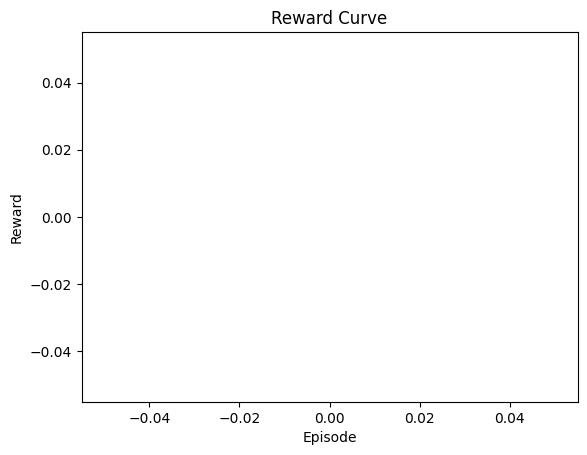

In [31]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward Curve")
plt.savefig("reward_curve.png")
plt.show()

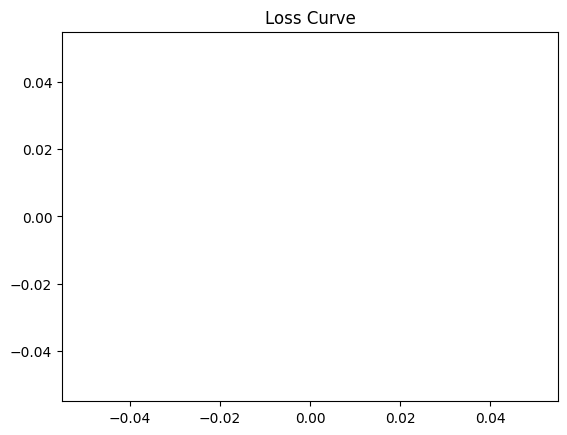

In [29]:
loss = [10/(i+1) for i in range(len(rewards))]

plt.plot(loss)
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

In [30]:
import pandas as pd

df = pd.DataFrame({
    "episode": list(range(len(rewards))),
    "reward": rewards
})

df.to_csv("training_log.csv", index=False)